In [2]:
# Configure notebook environment
from src.utils.project_setup import configure_notebook

configure_notebook()

# Project data
from src.data.loader import load_features

# General libraries
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

# Explainability
import shap

# Visualization
import matplotlib.pyplot as plt
import plotly.express as px

Notebook configured successfully.


In [3]:
# Load trained XGBoost model from Notebook 06
xgb = joblib.load("../models/xgboost_model.joblib")

# Load engineered feature dataset
model_data = load_features()

print(f"Model data shape: {model_data.shape}")

Model data shape: (58327370, 38)


In [4]:
# Use the same recent-history window as Notebook 06
latest_date = model_data["date"].max()
cutoff_date = latest_date - pd.Timedelta(days=365)

model_data = model_data[
    model_data["date"] >= cutoff_date
].reset_index(drop=True)

print(f"Reduced model data shape: {model_data.shape}")

Reduced model data shape: (11159340, 38)


In [5]:
# Reduce memory usage before explainability analysis
float_cols = model_data.select_dtypes(include=["float64"]).columns
int_cols = model_data.select_dtypes(include=["int64"]).columns

model_data[float_cols] = model_data[float_cols].astype("float32")
model_data[int_cols] = model_data[int_cols].astype("int32")

In [6]:
# Define target and remove non-model columns
TARGET = "sales"

columns_to_drop = [
    "sales",
    "id",
    "item_id",
    "date",
    "d",
    "wm_yr_wk",
    "weekday",
    "event_name_1",
    "event_name_2",
]

X = model_data.drop(columns=columns_to_drop)
y = model_data[TARGET]

In [7]:
# Encode categorical variables the same way as Notebook 06
categorical_columns = [
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_type_1",
    "event_type_2",
]

for column in categorical_columns:
    X[column] = (
        X[column]
        .astype("category")
        .cat.codes
        .astype("int16")
    )

In [8]:
# Recreate chronological validation and test split
dates = np.sort(model_data["date"].unique())

train_end = dates[-56]
validation_end = dates[-28]

validation_mask = (
    (model_data["date"] >= train_end) &
    (model_data["date"] < validation_end)
)

test_mask = model_data["date"] >= validation_end

X_valid = X.loc[validation_mask]
X_test = X.loc[test_mask]

y_valid = y.loc[validation_mask]
y_test = y.loc[test_mask]

print("Validation:", X_valid.shape)
print("Test:", X_test.shape)

Validation: (853720, 29)
Test: (853720, 29)


In [9]:
# Sample test data for SHAP analysis
X_shap = X_test.sample(
    n=min(5000, len(X_test)),
    random_state=42
)

print(X_shap.shape)

(5000, 29)


In [10]:
# Create SHAP explainer for the trained XGBoost model
explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_shap)

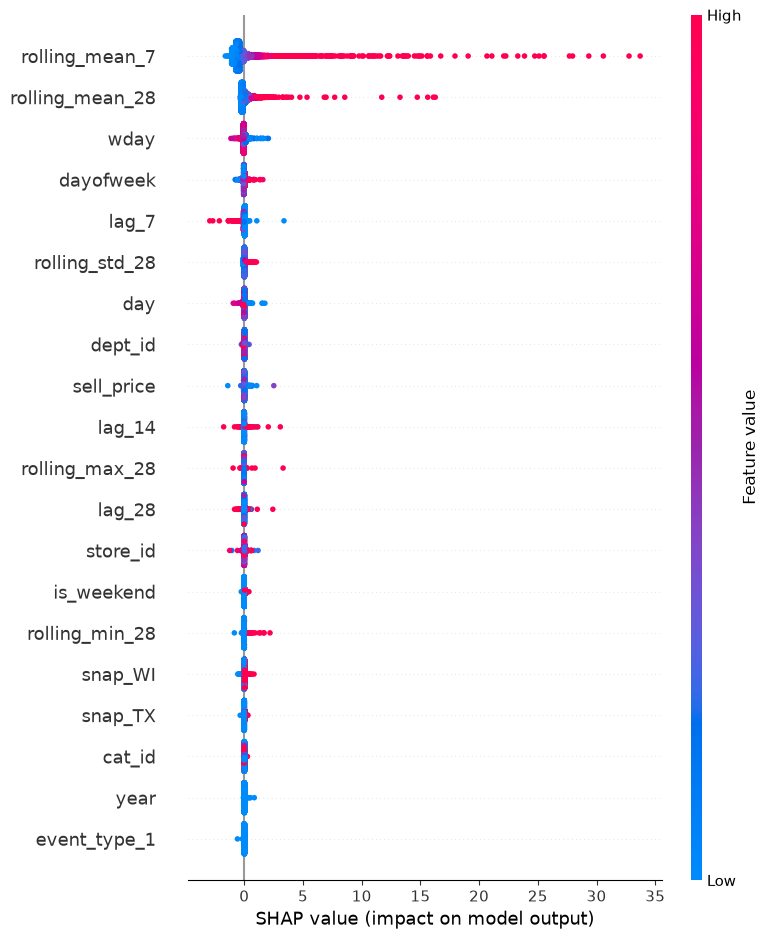

In [11]:
# Show global feature impact
shap.summary_plot(
    shap_values,
    X_shap,
    max_display=20
)

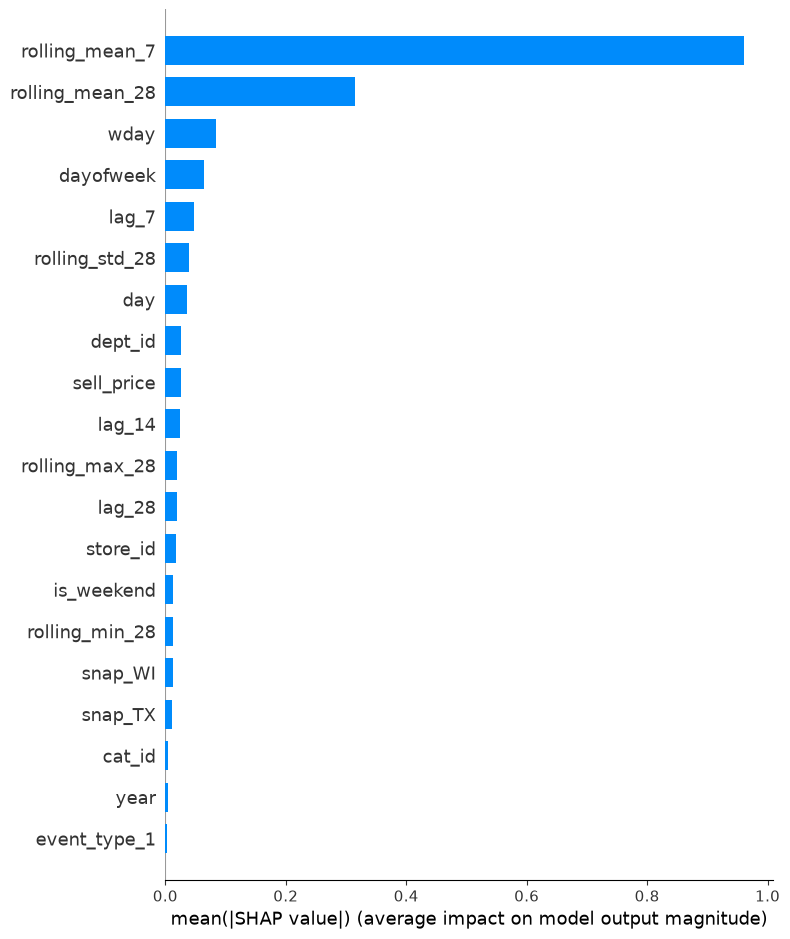

In [12]:
# Show mean absolute SHAP importance
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=20
)

In [13]:
# Convert SHAP values into a feature importance table
shap_importance = pd.DataFrame({
    "Feature": X_shap.columns,
    "Mean_Absolute_SHAP": np.abs(shap_values).mean(axis=0)
}).sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
)

shap_importance.to_csv(
    "../outputs/shap_feature_importance.csv",
    index=False
)

shap_importance.head(20)

,Feature,Mean_Absolute_SHAP
21,rolling_mean_7,0.960613
22,rolling_mean_28,0.315025
4,wday,0.083855
15,dayofweek,0.063448
18,lag_7,0.046835
23,rolling_std_28,0.039788
14,day,0.036798
0,dept_id,0.026142
12,sell_price,0.025610
19,lag_14,0.023701


SHAP analysis explains which features most strongly influenced the XGBoost demand forecasts.

The key question is whether the model relies primarily on:

- Recent demand signals
- Rolling demand trends
- Price effects
- Calendar effects
- Store and product category differences

This helps convert the model from a black-box forecasting tool into an explainable decision-support asset.

In [14]:
xgb_importance = pd.read_csv("../outputs/feature_importance.csv")
shap_importance = pd.read_csv("../outputs/shap_feature_importance.csv")

comparison = (
    xgb_importance
    .merge(
        shap_importance,
        on="Feature"
    )
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
)

comparison.head(20)

,Feature,Importance,Mean_Absolute_SHAP
0,rolling_mean_7,0.597244,0.960613
1,rolling_mean_28,0.190082,0.315025
5,wday,0.009119,0.083855
7,dayofweek,0.008369,0.063448
3,lag_7,0.015098,0.046835
13,rolling_std_28,0.006302,0.039788
17,day,0.004571,0.036798
23,dept_id,0.003412,0.026142
11,sell_price,0.006672,0.025610
6,lag_14,0.008481,0.023701
